# Flow past a circular cylinder: drag, lift and the Strouhal number

The most demanding example: a cylinder (diameter $D$) in a uniform stream $U$ at $\mathrm{Re}=UD/\nu=100$, where the wake sheds a von Kármán vortex street. The quantities to compare are the
integrated *wall loads* — the mean drag coefficient $C_D$, the amplitude of the lift $C_L$ — and the **Strouhal number** $\mathrm{St}=fD/U$ of the lift oscillation. Unconfined literature values
(Williamson 1996; Dennis & Chang 1970; Fornberg 1980):

| Re | $C_D$ | $C_{L,\mathrm{amp}}$ | St | $L_w/D$ |
|---|---|---|---|---|
| 20 | 2.00–2.09 | – | – | 0.91–0.94 |
| 40 | 1.50–1.55 | – | – | 2.2–2.35 |
| 100 | 1.33–1.35 | 0.32–0.34 | 0.164–0.166 | – |

**Set-up.** The stream is a periodic box with a *prescribed-velocity frame*: a band of fluid particles around the box seams moves with the free stream (`Pinned`), so the stream re-enters at the inlet
and the boundary needs no inflow/outflow condition; the cylinder is one exact analytic disk. The confinement of a finite box raises $C_D$ and St by a few per cent over the unconfined values
(blockage $D/(L_y-2b)$ is printed). Both solvers take the same band.

**Cost.** This is the one expensive example (the wake needs a long record to settle; the step costs ~1 ms per 1000 particles).

* `QUALITY="quick"`: **Re = 20**, the steady wake, D/dx = 12, box 16 × 12 (about 28 000 particles, ~10 minutes): the drag coefficient (and the recirculation length) against the literature table;
* `QUALITY="full"`: **Re = 100**, the shedding wake, D/dx = 14, box 22 × 11 (about 50 000 particles, **hours**): drag, lift amplitude and the Strouhal number. The series of a run of this repository is stored
  (`results/examples/flow_past_cylinder_full_<scheme>.npz`); set `LOAD_STORED = True` to plot it without running.

In [1]:
SCHEME = "delta"      # "delta" | "dfsph"
QUALITY = "quick"     # "quick" | "full"
DEVICE = "cuda:0"
LOAD_STORED = False   # True: do not run, plot the stored series of an earlier run (results/examples/flow_past_cylinder_<scheme>.npz)

In [2]:
import math, time
import numpy as np
import matplotlib.pyplot as plt

import warpSPHBoundaries  # noqa: F401
from warpSPHBoundaries.scene.periodic import Periodic
from warpSPHBoundaries.scene.scene import Body, DiskArrayRep, Scene
from warpSPHBoundaries.sim.dfsph2d import carve, lattice_calibration, PACKING
from warpSPHBoundaries.sim.loads import coefficients, strouhal
from warpSPHBoundaries.sim.pinned import Pinned
from warpSPHBoundaries.sim.references import CYLINDER_WAKE
from warpSPHBoundaries.sim.solvers import make_solver, lattice, save_series, load_series

cfg = {"quick": dict(Re=20.0, res=12, Lx=16.0, Ly=12.0, xb=6.0, T=20.0), "full": dict(Re=100.0, res=14, Lx=22.0, Ly=11.0, xb=7.5, T=120.0)}[QUALITY]
Re, D, U = cfg["Re"], 1.0, 1.0
band, xb = 1.5, cfg["xb"]
dx = D / cfg["res"]
nx, ny = int(round(cfg["Lx"] / dx)), int(round(cfg["Ly"] / dx))
Lx, Ly = nx * dx, ny * dx
nu = U * D / Re
print(f"scheme {SCHEME}, Re = {Re:g}, D/dx = {cfg['res']}, box {Lx:g} x {Ly:g} D, frame half width {band} D, blockage D/(Ly-2b) = {D / (Ly - 2 * band):.3f}, T = {cfg['T']} D/U")

scheme delta, Re = 20, D/dx = 12, box 16 x 12 D, frame half width 1.5 D, blockage D/(Ly-2b) = 0.111, T = 20.0 D/U


## Set-up

In [3]:
if not LOAD_STORED:
    pos = lattice((0, 0), (Lx, Ly), dx)
    body = Body(bodyId=0, center=(xb, Ly / 2), reps=[DiskArrayRep([(0.0, 0.0)], [0.5 * D])])
    if SCHEME == "delta":
        pos = pos[np.linalg.norm(pos - [xb, Ly / 2], axis=1) >= 0.5 * D + 0.5 * dx]
    else:
        cal = lattice_calibration(dx, dx, dx / PACKING)
        pos = carve(pos, [body], dx / PACKING, cal["lamCell"], DEVICE)
    vel = np.tile([U, 0.0], (len(pos), 1))                                  # impulsive start in the uniform stream
    frame = Pinned(slabs=((0, 0.0, band), (1, 0.0, band)), velocity=(U, 0.0))
    extra = {"maxDt": 0.05} if SCHEME == "dfsph" else {}
    sol = make_solver(SCHEME, pos, dx, Scene([body], DEVICE), nu=nu, vel=vel, periodic=Periodic((0, 0), (Lx, Ly)), pinned=frame, c0=10 * U, device=DEVICE, **extra)
    print(f"N = {sol.n}, dt = {sol.dt:.3e}")
    rec = []
    def record(s):
        rec.append((s.time, *s.loads(0)))

N = 27524, dt = 5.270e-03


## Integration (the long cell)

In [4]:
if not LOAD_STORED:
    t0 = time.time()
    sol.run(cfg["T"], every=cfg["T"] / 8, callback=record, report=lambda s: f"C_D (last 2 D/U) = {np.mean([r[1] for r in rec[-int(2 / max(s.dt, 1e-9)):]]) * 2 / (U * U * D):.3f}")
    a = np.array(rec)
    save_series(f"flow_past_cylinder_{QUALITY}", SCHEME, t=a[:, 0], Fx=a[:, 1], Fy=a[:, 2], T=cfg["T"], res=cfg["res"], Re=Re)
    wall = time.time() - t0
else:
    z = load_series(f"flow_past_cylinder_{QUALITY}", SCHEME)
    a = np.stack([z["t"], z["Fx"], z["Fy"]], 1); cfg["T"] = float(z["T"]); wall = float("nan")

  t    2.503  dt 5.27e-03  vmax    1.335  C_D (last 2 D/U) = 2.875  [63 s]


  t    5.002  dt 5.27e-03  vmax    1.337  C_D (last 2 D/U) = 2.726  [133 s]


  t    7.505  dt 5.27e-03  vmax    1.325  C_D (last 2 D/U) = 2.596  [223 s]


  t   10.003  dt 5.27e-03  vmax    1.314  C_D (last 2 D/U) = 2.522  [310 s]


  t   12.502  dt 5.27e-03  vmax    1.308  C_D (last 2 D/U) = 2.510  [378 s]


  t   15.005  dt 5.27e-03  vmax    1.306  C_D (last 2 D/U) = 2.517  [441 s]


  t   17.503  dt 5.27e-03  vmax    1.305  C_D (last 2 D/U) = 2.521  [504 s]


  t   20.001  dt 5.27e-03  vmax    1.306  C_D (last 2 D/U) = 2.525  [567 s]


## Coefficients and Strouhal number

delta, Re = 20, D/dx = 12:  C_D = 2.523  (567 s)
literature (unconfined) C_D 2.0-2.09, L_w/D 0.91-0.94;  this box has blockage 0.11, which raises C_D (and St) by several per cent


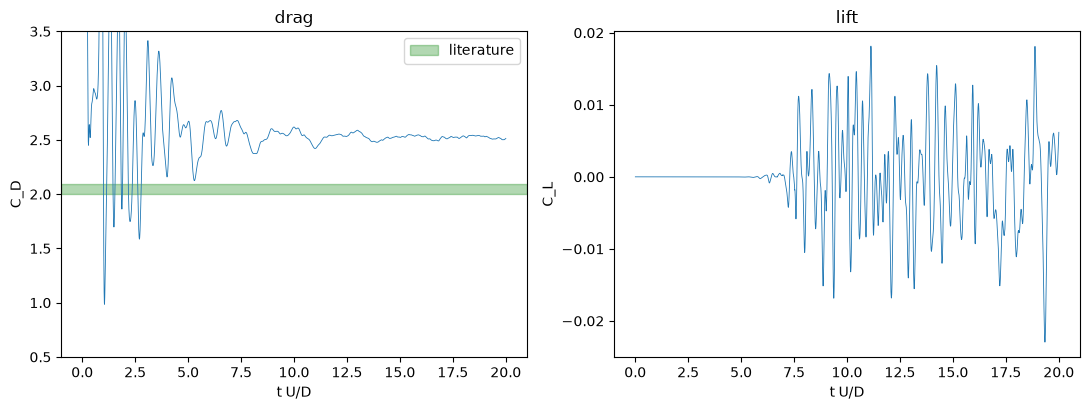

In [5]:
t = a[:, 0]
cd, cl = coefficients(a[:, 1:3], 1.0, U, D)
m = t >= (0.5 if Re > 60 else 0.7) * cfg["T"]                    # the last part of the record (after the start-up / the onset of shedding)
ref = CYLINDER_WAKE[int(Re)]
print(f"{SCHEME}, Re = {Re:g}, D/dx = {cfg['res']}:  C_D = {cd[m].mean():.3f}  ({wall:.0f} s)")
print(f"literature (unconfined) C_D {ref['CD'][0]}-{ref['CD'][1]}" + (f", C_L amplitude {ref['CLamp'][0]}-{ref['CLamp'][1]}, St {ref['St'][0]}-{ref['St'][1]}" if Re > 60 else f", L_w/D {ref['Lw'][0]}-{ref['Lw'][1]}") + f";  this box has blockage {D / (Ly - 2 * band):.2f}, which raises C_D (and St) by several per cent")
St = float("nan")
def lift_spectrum(t, y, t0, lo=0.05, hi=0.5):
    """spectrum of the lift after t0, on a uniform grid, Hann window; returns (St axis, normalised amplitude, St of the largest peak in [lo, hi]). The band excludes the low-frequency drift of the start-up and the
    high-frequency noise of the weakly compressible wall load."""
    tt = np.arange(t0, t[-1], 0.05); yy = np.interp(tt, t, y); yy = yy - yy.mean()
    sp = np.abs(np.fft.rfft(yy * np.hanning(len(yy)))); fr = np.fft.rfftfreq(len(yy), 0.05)
    band = (fr >= lo) & (fr <= hi)
    return fr, sp / sp[band].max(), float(fr[band][np.argmax(sp[band])])
if Re > 60:
    amp = 0.5 * (np.percentile(cl[m], 99) - np.percentile(cl[m], 1))
    fr, sp, St = lift_spectrum(t, cl, t0=0.3 * cfg["T"])
    print(f"C_L rms = {cl[m].std():.3f}   amplitude (1-99 %) = {amp:.3f}   St (peak of the lift spectrum, record after 0.3 T) = {St:.4f}")

fig, ax = plt.subplots(1, 3 if Re > 60 else 2, figsize=(16 if Re > 60 else 11, 4.2))
ax[0].plot(t, cd, lw=0.6); ax[0].axhspan(*ref["CD"], color="g", alpha=0.3, label="literature"); ax[0].set(xlabel="t U/D", ylabel="C_D", title="drag", ylim=(0.5, 3.5)); ax[0].legend()
ax[1].plot(t, cl, lw=0.6); ax[1].set(xlabel="t U/D", ylabel="C_L", title=f"lift" + (f" (St = {St:.3f})" if Re > 60 else ""))
if Re > 60:
    ax[1].axhspan(ref["CLamp"][0], ref["CLamp"][1], color="g", alpha=0.3); ax[1].axhspan(-ref["CLamp"][1], -ref["CLamp"][0], color="g", alpha=0.3)
    ax[2].plot(fr, sp); ax[2].axvspan(*ref["St"], color="g", alpha=0.4); ax[2].set(xlabel="St = f D/U", ylabel="|FFT| / peak", title="spectrum of the lift", xlim=(0, 0.6))
plt.tight_layout(); plt.show()

## What to look at

* the **drag**: at Re = 20 the quick run gives $C_D\approx2.52$ for **both** solvers (delta 2.52, dfsph 2.53) against 2.0–2.09 for the unconfined cylinder. The two schemes agree with each other; the excess is the
  confinement of the box (blockage and the Dirichlet frame: the same dfsph run in a box of free height 5 D instead of 9 D gives 3.2 — the drag falls steeply as the box widens) and the coarse resolution
  (D/dx = 12). A converged comparison needs a wider box and D/dx of 20 or more;
* the **lift** is zero for a symmetric flow, so the shedding starts only when numerical noise breaks the symmetry: the time of onset (and thus the usable part of the record) is not reproducible across
  resolutions and schemes. If the lift stays flat, lengthen `T`;
* the **Strouhal number** from the spectrum of the lift needs several shedding periods ($1/\mathrm{St}\approx6$ time units); the `quick` run has a few at best.

Converged reference runs of this repository (`scripts/studies/cylinder_wake.py`, delta, D/dx = 20, box 30 x 15): see `docs/plan-next-steps.md`, rung 5.